In [3]:
import prism
from pathlib import Path
from imagematerials.factory import ModelFactory, Sector
from imagematerials.maintenance import Maintenance, MaintenanceLinear
from imagematerials.concepts import knowledge_graph
from plotting import plot_maintenance_production_comparison, material_colors, maintenance_types, type_colors
import matplotlib.pyplot as plt
import pickle as pkl
import os

from imagematerials.model import (
    GenericMaterials,
    GenericStocks
)
import warnings
from imagematerials.preprocessing import get_preprocessing_data

In [4]:
# Define simulation parameters
time_start = 1920
complete_timeline = prism.Timeline(time_start, 2100, 1)
simulation_timeline = prism.Timeline(1920, 2100, 1)

scenario_list2 = {
    'standard_linear': {
        'label': 'Standard Lifetimes & Linear Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'linear'
    },
    'standard_constant': {
        'label': 'Standard Lifetimes & Regular Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'constant'
    },
    'slow_constant': {
        'label': 'Slow Lifetimes & Regular Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'constant'
    },
    'slow_linear': {
        'label': 'Slow Lifetimes & Linear Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'linear'
    }
}

scenario_list = {

    'standard_constant': {
        'label': 'Standard Lifetimes & Regular Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'constant'
    },
}

In [38]:
base_dir = Path("..", "..", "image-materials", "data", "raw")
vhc_sector = get_preprocessing_data("vehicles", base_dir, cache = "vhc_sector2.nc")

circular_economy_scenario_dirs = {
        "slow": base_dir / 'circular_economy_scenarios' / 'slow'
    }
climate_policy_scenario_dir = base_dir / "IMAGE_CircoMod" / 'SSP2'

vhc_sector_slow = get_preprocessing_data("vehicles", base_dir, climate_policy_scenario_dir, circular_economy_scenario_dirs, cache = "vhc_sector_slow2.nc")


Total number of cars in 2016 (millions): 952.33 million

Total number of cars (in millions):
----------------------------------------
Year      Cars (millions)% of 2020 value     
----------------------------------------
1971      269.43         30.7                %
1980      396.24         45.1                %
1990      488.85         55.7                %
2000      629.75         71.7                %
2010      813.43         92.6                %
2020      878.40         100.0               %
----------------------------------------
implemented 'slow' for Vehicles
Total number of cars in 2016 (millions): 1156.07 million

Total number of cars (in millions):
----------------------------------------
Year      Cars (millions)% of 2020 value     
----------------------------------------
1971      272.39         23.6                %
1980      397.70         34.4                %
1990      521.61         45.2                %
2000      711.41         61.6                %
2010      954.

In [6]:
all_output = {}

for scen_id, scenario_config in scenario_list.items():   
    pkl_path = f"{scen_id}.pkl"
    if not os.path.exists(pkl_path):
        print(f"\n=== Running Scenario: {scen_id} ===")
        
        # Select the appropriate sector data based on circular economy scenario
        if scenario_config['circular_scen'] == 'standard':
            sector_data = vhc_sector
            print("Using standard sector data")
        elif scenario_config['circular_scen'] == 'slow':
            sector_data = vhc_sector_slow
            print("Using slow circular economy sector data")
        
        # Create factory with appropriate sector data
        factory = ModelFactory(
            sector_data, complete_timeline
        ).add(GenericStocks
        ).add(GenericMaterials)
        
        # Add the appropriate maintenance model based on maintenance scenario
        if scenario_config['maintenance_scen'] == 'constant':
            factory = factory.add(Maintenance)
            print("Using constant maintenance model")
        elif scenario_config['maintenance_scen'] == 'linear':
            # Pass vehicle_lifetimes as an explicit parameter to MaintenanceLinear
            factory = factory.add(MaintenanceLinear)
            print("Using linear maintenance model with explicit vehicle lifetimes")
        
        # Finish model creation
        model = factory.finish()
        
        # Run simulation
        
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            model.simulate(simulation_timeline)
        
        # Store results
        all_output[scen_id] = {
            'model': model,
            'inflow_maintenance': model.inflow_maintenance.to_array(),
            'circular_scenario': scenario_config['circular_scen'],
            'maintenance_scenario': scenario_config['maintenance_scen'],
            'label': scenario_config['label']
        }
        
        print(f"✓ Completed: {scen_id}")
        all_output[scen_id]["model"].save_pkl(pkl_path)
        print(f"\n=== All {len(all_output)} scenarios completed successfully ===")
    else:
        with open(pkl_path, "rb") as handle:
            model = pkl.load(handle)

                # Store results in the same format as when we calculate it
        all_output[scen_id] = {
            'model': model['vehicles'],
            'inflow_maintenance': model['vehicles']['inflow_maintenance'].to_array(),
            'circular_scenario': scenario_config['circular_scen'],
            'maintenance_scenario': scenario_config['maintenance_scen'],
            'label': scenario_config['label']
        }
        print(f"✓ Loaded: {scen_id}")


print("Available scenarios:", list(all_output.keys()))


✓ Loaded: standard_constant
Available scenarios: ['standard_constant']


In [41]:
pd.read_csv("VEMA_vehicle_stock.csv", index_col=0).T

elements,Bicycles,Cars,Planes,Trains,Buses,Rail Cargo,Air Cargo,Trucks,Ships
2000,2.318354e+10,8.255608e+11,4.497906e+08,1.264784e+10,1.089315e+11,1.279118e+11,3.387493e+08,2.664625e+11,1.636799e+11
2001,2.330765e+10,8.570656e+11,4.477488e+08,1.282451e+10,1.121979e+11,1.264213e+11,3.431265e+08,2.645896e+11,1.635553e+11
2002,2.340136e+10,8.757858e+11,4.470347e+08,1.312236e+10,1.159008e+11,1.257124e+11,3.479829e+08,2.695443e+11,1.639970e+11
2003,2.361490e+10,8.997808e+11,4.481335e+08,1.319749e+10,1.183006e+11,1.264552e+11,3.542867e+08,2.801231e+11,1.669079e+11
2004,2.366055e+10,9.334327e+11,5.097392e+08,1.359443e+10,1.225226e+11,1.287601e+11,4.026447e+08,3.008997e+11,1.725388e+11
...,...,...,...,...,...,...,...,...,...
2056,2.308415e+10,1.495260e+12,5.212068e+08,7.208124e+10,1.840018e+11,2.944330e+11,7.458036e+08,1.007402e+12,2.526522e+11
2057,2.296026e+10,1.500136e+12,5.163733e+08,7.466633e+10,1.837110e+11,2.963891e+11,7.422651e+08,1.014088e+12,2.536330e+11
2058,2.282629e+10,1.504976e+12,5.119163e+08,7.707733e+10,1.833281e+11,2.983349e+11,7.389851e+08,1.021101e+12,2.546752e+11
2059,2.268458e+10,1.510093e+12,5.079751e+08,7.928641e+10,1.828468e+11,3.003185e+11,7.360363e+08,1.028416e+12,2.557812e+11


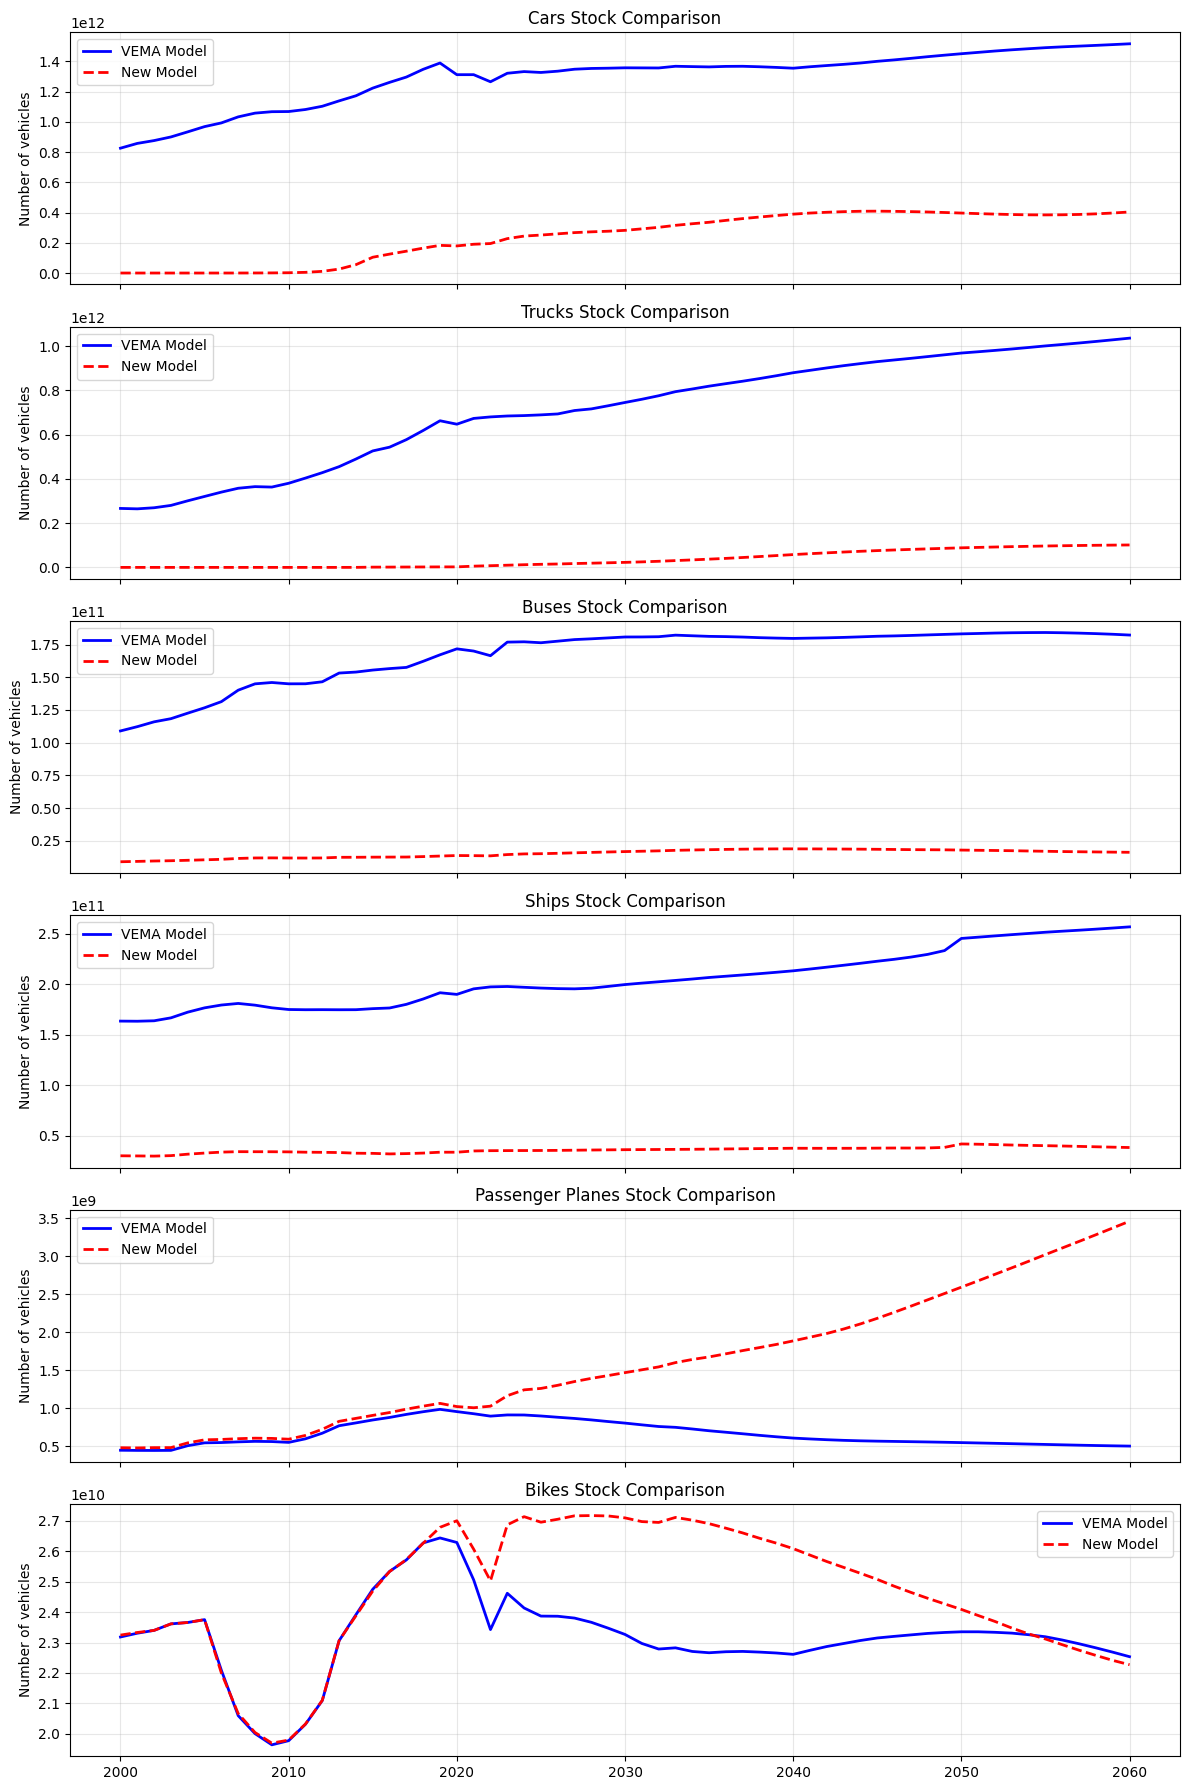


Comparison between VEMA and New Model:
Year    Vehicle Type   VEMA Model     New Model      Difference  % Diff    
----------------------------------------------------------------------
2000    Cars           8.26e+11       3.47e+08       -8.25e+11   -100.0    %
2000    Trucks         2.66e+11       9.23e+05       -2.66e+11   -100.0    %
2000    Buses          1.09e+11       8.92e+09       -1.00e+11   -91.8     %
2000    Ships          1.64e+11       3.04e+10       -1.33e+11   -81.4     %
2000    Passenger Planes4.50e+08       4.83e+08       3.32e+07    7.4       %
2000    Bikes          2.32e+10       2.32e+10       6.24e+07    0.3       %
----------------------------------------------------------------------
2020    Cars           1.31e+12       1.79e+11       -1.13e+12   -86.3     %
2020    Trucks         6.47e+11       2.32e+09       -6.45e+11   -99.6     %
2020    Buses          1.72e+11       1.37e+10       -1.58e+11   -92.0     %
2020    Ships          1.90e+11       3.39e+10  

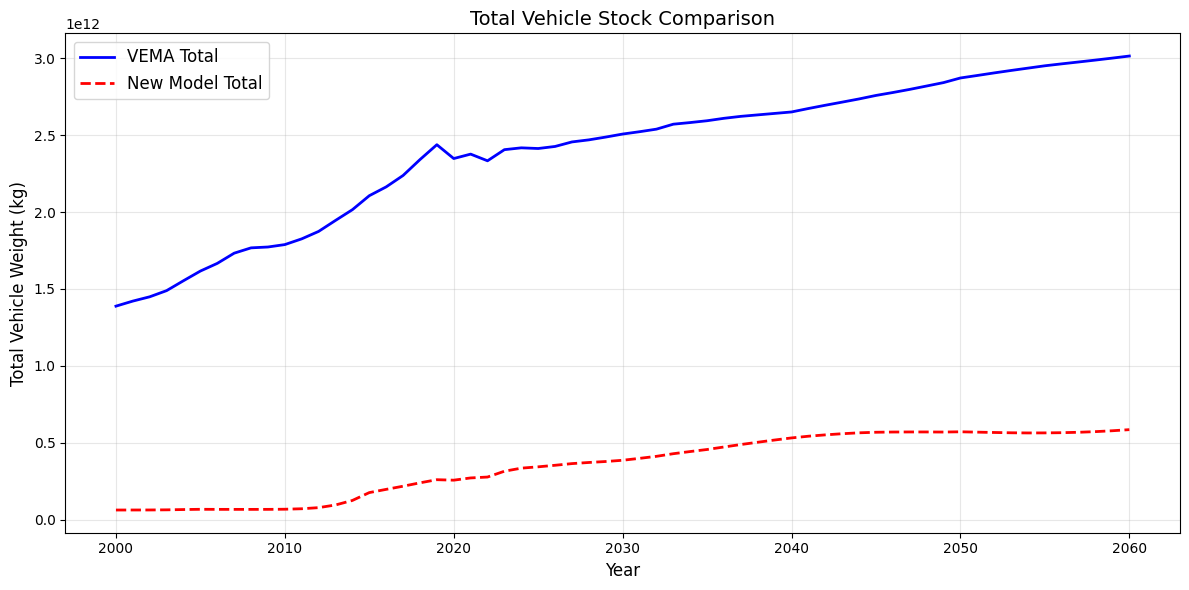

In [44]:
#all_output['standard_constant']['model'].stocks
import pandas as pd
import numpy as np

comparison_types = ["Cars","Trucks","Buses","Ships","Passenger Planes","Bikes"]


old_stock = pd.read_csv("VEMA_vehicle_stock.csv", index_col=0).T
old_stock.index = old_stock.index.astype(int)
old_stock = old_stock.rename(columns={'Planes': 'Passenger Planes','Bicycles': 'Bikes'})

new_stock_all = all_output["standard_constant"]["model"]["stock_by_cohort_materials"].sum(dim=["Region","material"])
new_stock_df = knowledge_graph.rebroadcast_xarray(new_stock_all, output_coords=comparison_types, dim="Type").to_pandas()

start_year = 2000
end_year = 2060

old_stock_filtered = old_stock.loc[start_year:end_year] 
new_stock_filtered = new_stock_df.loc[start_year:end_year] 

common_columns = [col for col in comparison_types if col in old_stock_filtered.columns]
old_stock_filtered = old_stock_filtered[common_columns]
new_stock_filtered = new_stock_filtered[common_columns]

fig, axs = plt.subplots(len(comparison_types), 1, figsize=(12, 3*len(comparison_types)), sharex=True)

for i, vehicle_type in enumerate(comparison_types):
    ax = axs[i]
    
    # Plot old stock if the vehicle type exists in old_stock
    if vehicle_type in old_stock_filtered.columns:
        ax.plot(old_stock_filtered.index, old_stock_filtered[vehicle_type], 
                'b-', label='VEMA Model', linewidth=2)
    
    # Plot new stock
    ax.plot(new_stock_filtered.index, new_stock_filtered[vehicle_type], 
            'r--', label='New Model', linewidth=2)
    
    ax.set_title(f'{vehicle_type} Stock Comparison')
    ax.set_ylabel('Number of vehicles')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# 5. Calculate percentage differences and create a summary table
print("\nComparison between VEMA and New Model:")
print("="*70)
print(f"{'Year':<8}{'Vehicle Type':<15}{'VEMA Model':<15}{'New Model':<15}{'Difference':<12}{'% Diff':<10}")
print("-"*70)

sample_years = [2000, 2020,2040,  2060]
sample_years = [y for y in sample_years if y in old_stock_filtered.index and y in new_stock_filtered.index]

for year in sample_years:
    for vehicle_type in comparison_types:
        if vehicle_type in old_stock_filtered.columns:
            old_val = old_stock_filtered.loc[year, vehicle_type] if year in old_stock_filtered.index else np.nan
            new_val = new_stock_filtered.loc[year, vehicle_type] if year in new_stock_filtered.index else np.nan
            
            if not np.isnan(old_val) and not np.isnan(new_val):
                diff = new_val - old_val
                pct_diff = (diff / old_val) * 100 if old_val != 0 else np.nan
                
                print(f"{year:<8}{vehicle_type:<15}{old_val:<15.2e}{new_val:<15.2e}{diff:<12.2e}{pct_diff:<10.1f}%")
    
    print("-"*70)

# 6. Plot total vehicle stock comparison
old_total = old_stock_filtered.sum(axis=1) if not old_stock_filtered.empty else pd.Series()
new_total = new_stock_filtered.sum(axis=1)

plt.figure(figsize=(12, 6))
if not old_total.empty:
    plt.plot(old_total.index, old_total, 'b-', label='VEMA Total', linewidth=2)
plt.plot(new_total.index, new_total, 'r--', label='New Model Total', linewidth=2)

plt.title('Total Vehicle Stock Comparison', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel("Total Vehicle Weight (kg)", fontsize=12)
ax.set_yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [28]:
old_stock_filtered

elements,Bicycles,Cars,Planes,Trains,Buses,Rail Cargo,Air Cargo,Trucks,Ships
2000,2.318354e+10,8.255608e+11,4.497906e+08,1.264784e+10,1.089315e+11,1.279118e+11,3.387493e+08,2.664625e+11,1.636799e+11
2001,2.330765e+10,8.570656e+11,4.477488e+08,1.282451e+10,1.121979e+11,1.264213e+11,3.431265e+08,2.645896e+11,1.635553e+11
2002,2.340136e+10,8.757858e+11,4.470347e+08,1.312236e+10,1.159008e+11,1.257124e+11,3.479829e+08,2.695443e+11,1.639970e+11
2003,2.361490e+10,8.997808e+11,4.481335e+08,1.319749e+10,1.183006e+11,1.264552e+11,3.542867e+08,2.801231e+11,1.669079e+11
2004,2.366055e+10,9.334327e+11,5.097392e+08,1.359443e+10,1.225226e+11,1.287601e+11,4.026447e+08,3.008997e+11,1.725388e+11
...,...,...,...,...,...,...,...,...,...
2056,2.308415e+10,1.495260e+12,5.212068e+08,7.208124e+10,1.840018e+11,2.944330e+11,7.458036e+08,1.007402e+12,2.526522e+11
2057,2.296026e+10,1.500136e+12,5.163733e+08,7.466633e+10,1.837110e+11,2.963891e+11,7.422651e+08,1.014088e+12,2.536330e+11
2058,2.282629e+10,1.504976e+12,5.119163e+08,7.707733e+10,1.833281e+11,2.983349e+11,7.389851e+08,1.021101e+12,2.546752e+11
2059,2.268458e+10,1.510093e+12,5.079751e+08,7.928641e+10,1.828468e+11,3.003185e+11,7.360363e+08,1.028416e+12,2.557812e+11


In [29]:
new_stock_filtered

Type,Cars,Trucks,Buses,Ships,Airplanes
Time,,,,,
2000,2.534097e+05,6.452373e+01,1.342417e+06,4327.528398,8990.699440
2001,2.324372e+05,5.974743e+01,1.382864e+06,4306.487098,8940.006477
2002,2.135753e+05,5.669766e+01,1.428546e+06,4283.157211,9009.578742
2003,1.980819e+05,5.602901e+01,1.459514e+06,4349.381587,9018.620671
2004,1.887846e+05,5.823166e+01,1.510509e+06,4555.615438,10176.653027
...,...,...,...,...,...
2056,2.777311e+08,6.841312e+06,2.515298e+06,5706.127285,57865.345834
2057,2.792557e+08,6.916804e+06,2.491271e+06,5652.418664,59474.572900
2058,2.819746e+08,6.983150e+06,2.470173e+06,5596.501010,61105.086660


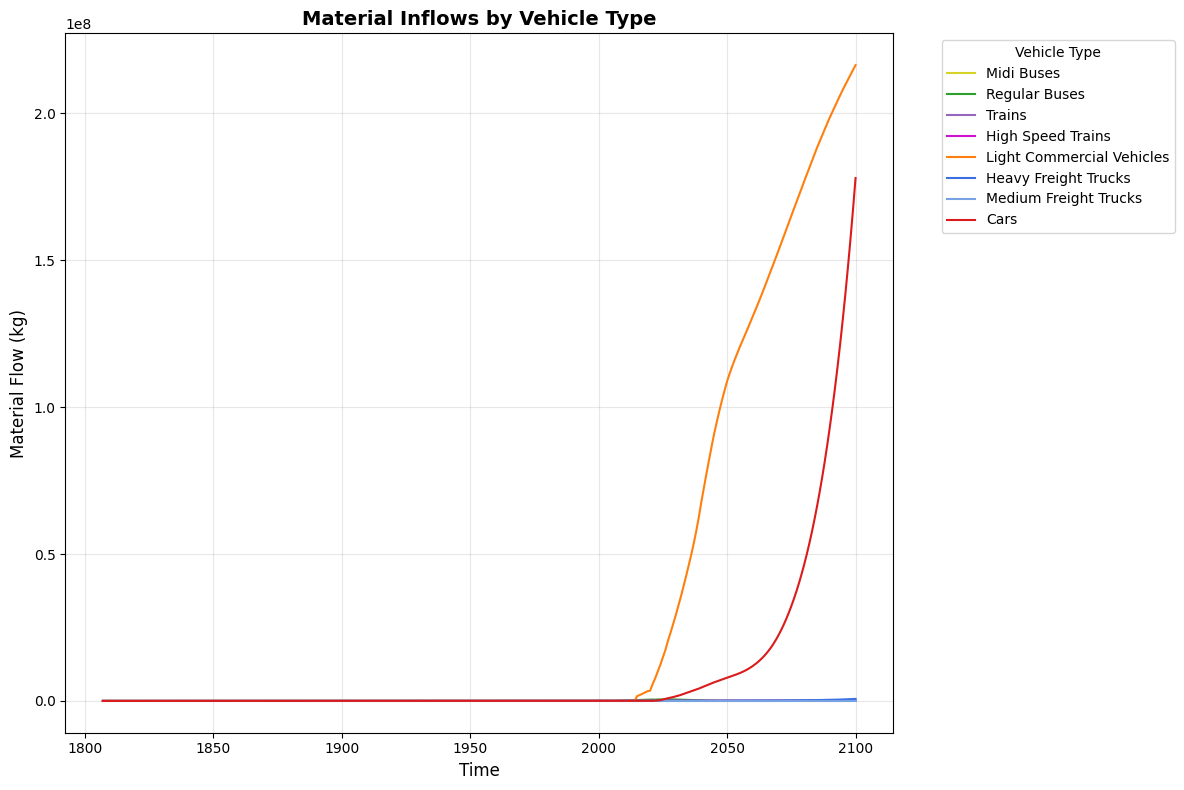

In [ ]:
types = [
    "Midi Buses",
    "Regular Buses", 
    "Trains",
    "High Speed Trains",
    "Light Commercial Vehicles",
    "Heavy Freight Trucks", "Medium Freight Trucks",
    "Cars"
]

materials = all_output["standard_constant"]["model"].stocks.sum(dim=["Region"])
rebroadcast_materials = knowledge_graph.rebroadcast_xarray(materials, output_coords=types, dim="Type")


# Create a figure first
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each vehicle type separately with explicit dimensions
for vehicle_type in rebroadcast_materials.coords["Type"].values:
    color = type_colors.get(vehicle_type, '#333333')  # Default to dark gray if not found
    data_for_type = rebroadcast_materials.sel(Type=vehicle_type)
    data_for_type.plot.line(ax=ax, label=vehicle_type, color=color)

# Customize plot appearance
ax.set_title('Material Inflows by Vehicle Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Material Flow (kg)', fontsize=12)
ax.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\repos\image-materials\scripts\plotting.py:352: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df_full = prod_df_full.fillna(method='bfill').fillna(method='ffill')  # Fill NaNs from rolling window


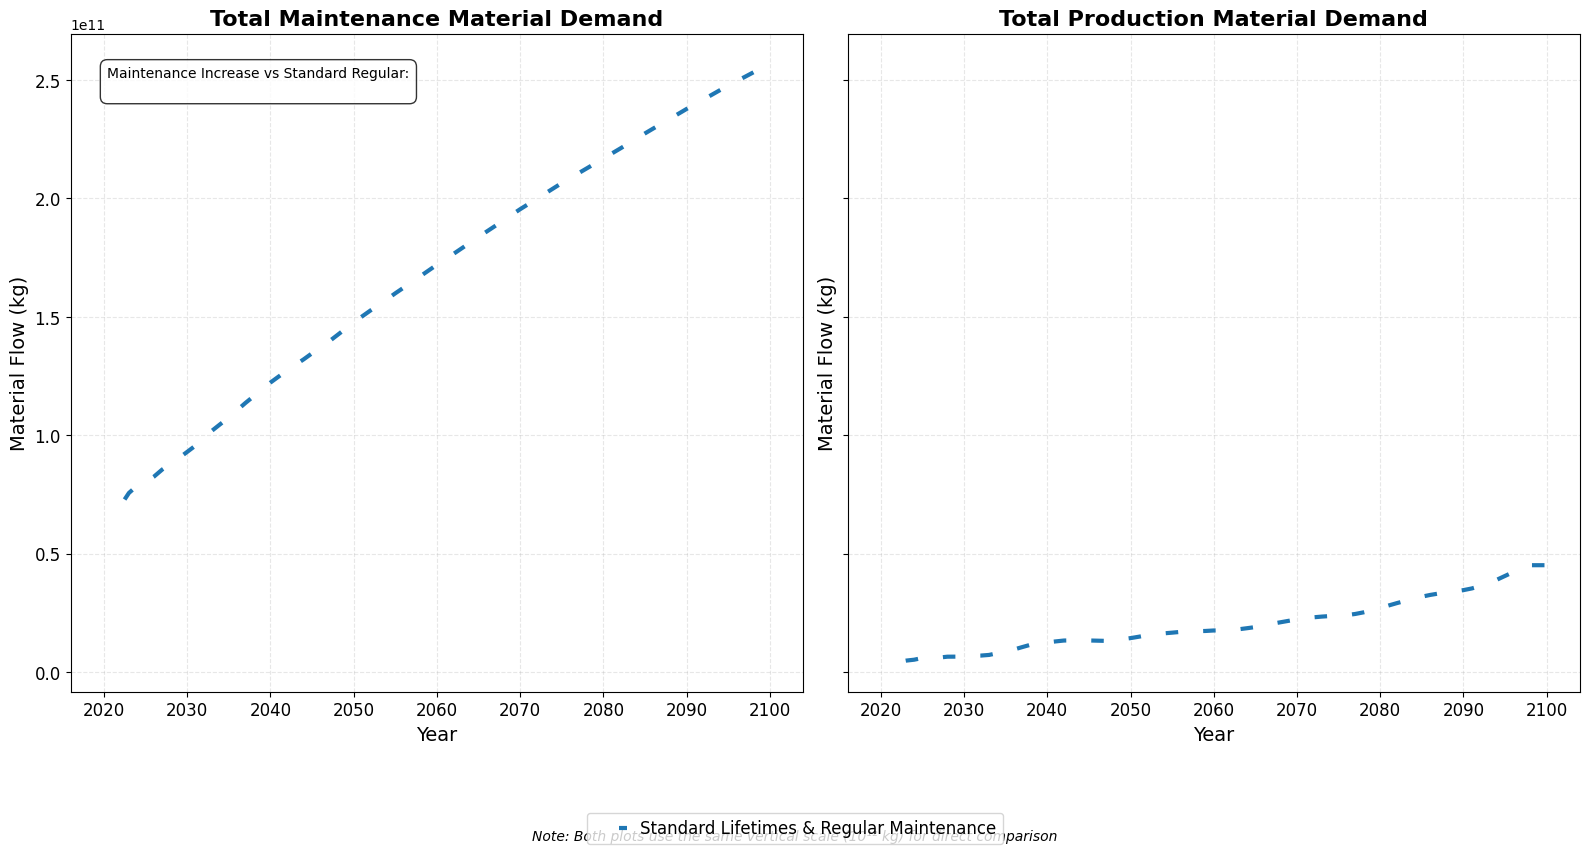


=== Summary Statistics (2050) ===
Standard Lifetimes & Regular Maintenance:
  Maintenance (2050): 1.48e+11 kg
  Production (2050): 1.23e+12 kg
  M/P Ratio: 0.120


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


In [ ]:
plot_maintenance_production_comparison(all_output, year_range=(2020, 2100))